# Trying out numpy to OpenFOAM format conversion:

In [1]:
import numpy as np
from pathlib import Path
import json
import Ofpp
import re
from repitframework import OpenFOAM

In [4]:
a = {'a': 1, 'b': 2, 'c': 3}
for i,key in enumerate(a.items()):
	print(i,key)

0 ('a', 1)
1 ('b', 2)
2 ('c', 3)


In [ ]:
p = "\n".join(map(str, np.random.rand(10, 3)))

In [52]:
data = np.pad(p.reshape(200,200,order="F"), 1, mode='constant', constant_values=0)
data

array([[     0.,      0.,      0., ...,      0.,      0.,      0.],
       [     0., 100112., 100112., ..., 100101., 100101.,      0.],
       [     0., 100112., 100112., ..., 100101., 100101.,      0.],
       ...,
       [     0., 100112., 100112., ..., 100101., 100101.,      0.],
       [     0., 100112., 100112., ..., 100101., 100101.,      0.],
       [     0.,      0.,      0., ...,      0.,      0.,      0.]])

In [ ]:
window_shape = (3, 3)
sliding_window = np.lib.stride_tricks.sliding_window_view(data, window_shape)
x,y = 1,1
correlated_features = np.stack([
	sliding_window[:,:,x,y],
	sliding_window[:,:,x-1,y],
	sliding_window[:,:,x+1,y],
	sliding_window[:,:,x,y-1],
	sliding_window[:,:,x,y+1]
],axis=-1)
correlated_features.reshape(-1,5)

array([[100112.,      0., 100112.,      0., 100112.],
       [100112., 100112., 100112.,      0., 100112.],
       [100112., 100112., 100112.,      0., 100112.],
       ...,
       [100101., 100101., 100101., 100101.,      0.],
       [100101., 100101., 100101., 100101.,      0.],
       [100101., 100101.,      0., 100101.,      0.]])

In [ ]:
with open("/home/openfoam/repitframework/repitframework/Solvers/natural_convection/3/p", "r") as f:
	foam_temp_data = f.read()
	foam_data_ = foam_data_ = re.sub(r'(location\s*)"([^"]*)"',rf'\1"{3}"',foam_temp_data) # update the location to the next time step
	foam_data = re.sub(r'\([\s\S]*?\)\n;', "ABC",foam_data_, count=1)

In [32]:
foam_data

'/*--------------------------------*- C++ -*----------------------------------*\\\n  =========                 |\n  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox\n   \\\\    /   O peration     | Website:  https://openfoam.org\n    \\\\  /    A nd           | Version:  11\n     \\\\/     M anipulation  |\n\\*---------------------------------------------------------------------------*/\nFoamFile\n{\n    format      ascii;\n    class       volScalarField;\n    location    "3";\n    object      p;\n}\n// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //\n\ndimensions      [1 -1 -2 0 0 0 0];\n\ninternalField   nonuniform List<scalar> \n40000\nABC\n\nboundaryField\n{\n    hot\n    {\n        type            calculated;\n        value           nonuniform List<scalar> \n200\n(\n100071\n100071\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100070\n100069\n100069\n1

In [ ]:
from pathlib import Path
import numpy as np
import struct

# Other functions like parse_internal_field, parse_boundary_content, etc., remain as they are

def write_field(fn, internal_field=None, boundary_field=None, binary=False):
	"""
	Write data back to OpenFOAM dictionary file with numpy array support.
	:param fn: File name to write
	:param internal_field: numpy array for the internal field
	:param boundary_field: dict of numpy arrays for each boundary
	:param binary: Whether to write in binary format
	"""
	content = []
	if internal_field is not None:
		content += write_internal_field(internal_field, binary)

	if boundary_field is not None:
		content += write_boundary_field(boundary_field, binary)

	with open(fn, "wb") as f:
		f.writelines(content)

def write_internal_field(internal_field, binary=False):
	"""
	Convert internal field numpy array to OpenFOAM dictionary format
	:param internal_field: numpy array
	:param binary: binary format or not
	:return: formatted string as a list of bytes lines
	"""
	if internal_field.ndim == 1:
		field_str = "internalField nonuniform List<scalar> {}\n".format(len(internal_field))
	else:
		field_str = "internalField nonuniform List<vector> {}\n".format(len(internal_field))

	lines = [field_str.encode()]
	
	if binary:
		header = b"("
		footer = b");\n"
		buf = struct.pack('c{}d'.format(internal_field.size), b'\0', *internal_field.flatten())
		lines.extend([header, buf, footer])
	else:
		lines.append(b"(\n")
		for value in internal_field:
			line = " ".join(map(str, value)) if internal_field.ndim > 1 else str(value)
			lines.append(f"{line}\n".encode())
		lines.append(b");\n")
	
	return lines

def write_boundary_field(boundary_field, binary=False):
	"""
	Convert boundary field dictionary to OpenFOAM dictionary format
	:param boundary_field: dict of numpy arrays for each boundary
	:param binary: binary format or not
	:return: formatted string as a list of bytes lines
	"""
	lines = [b"boundaryField\n{\n"]

	for boundary, field_data in boundary_field.items():
		lines.append(f"  {boundary.decode()} {{\n".encode())

		if isinstance(field_data, np.ndarray):
			field_lines = write_internal_field(field_data, binary=binary)
			lines.extend([b"    " + line for line in field_lines])
		elif isinstance(field_data, dict):
			for key, value in field_data.items():
				if key == "uniform":
					lines.append(f"    {key} uniform {value};\n".encode())
				elif key == "nonuniform":
					lines.extend(write_internal_field(np.array(value), binary=binary))
		
		lines.append(b"  }\n")

	lines.append(b"}\n")
	return lines


# Plotting CFD data

In [114]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

assets_dir = Path("/home/openfoam/repitframework/repitframework/logs/natural_convection")
metrics_dir = Path("/home/openfoam/repitframework/repitframework/Metrics/natural_convection")
metrics_dir.mkdir(exist_ok=True)
def visualize_output(assets_dir, timestamp):
	U = np.load(assets_dir / f"U_{timestamp}.npy")
	T = np.load(assets_dir / f"T_{timestamp}.npy")
	
	u_x = U[:,0].reshape(200,200,order="F")
	u_y = U[:,1].reshape(200,200,order="F")
	T = T.reshape(200,200,order="C")
	
	# flip the rows from top to bottom
	u_x = np.flipud(u_x)
	u_y = np.flipud(u_y)
	total_u = np.sqrt(u_x**2 + u_y**2)
	T = np.flipud(T)
	
	fig, ax = plt.subplots(1, 2, figsize=(10, 5))
	# u_x = ax[0].imshow(u_x, cmap="coolwarm")
	# fig.colorbar(u_x, ax=ax[0])
	# ax[0].set_title("Velocity X")
	# u_y = ax[1].imshow(u_y, cmap="coolwarm")
	# fig.colorbar(u_y, ax=ax[1])
	# ax[1].set_title("Velocity Y")
	total_u = ax[0].imshow(total_u, cmap="coolwarm")
	fig.colorbar(total_u, ax=ax[0])
	ax[0].set_title("Velocity Magnitude")
	T = ax[1].imshow(T, cmap="coolwarm")
	fig.colorbar(T, ax=ax[1])
	ax[1].set_title("Temperature")
	fig.tight_layout()
	fig.suptitle("At time={}s".format(timestamp))
	plt.savefig(metrics_dir / f"output_{timestamp}.png")

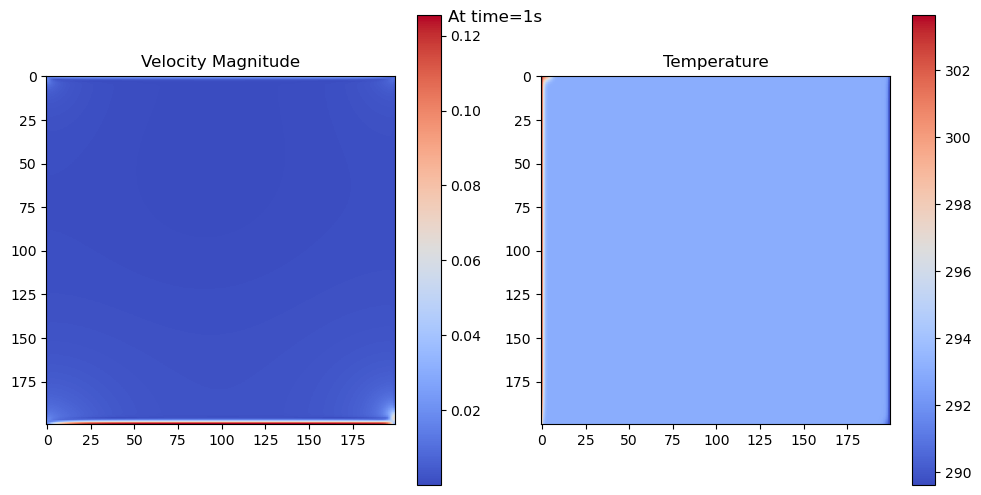

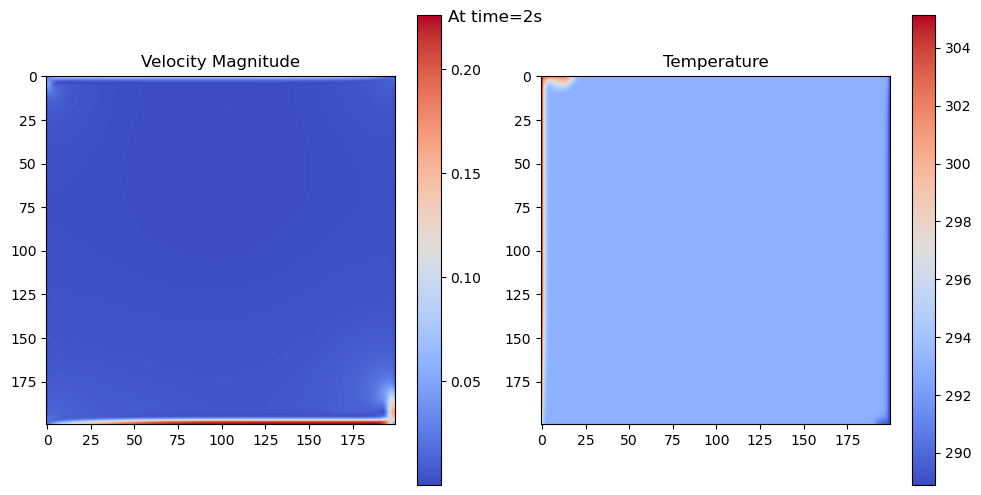

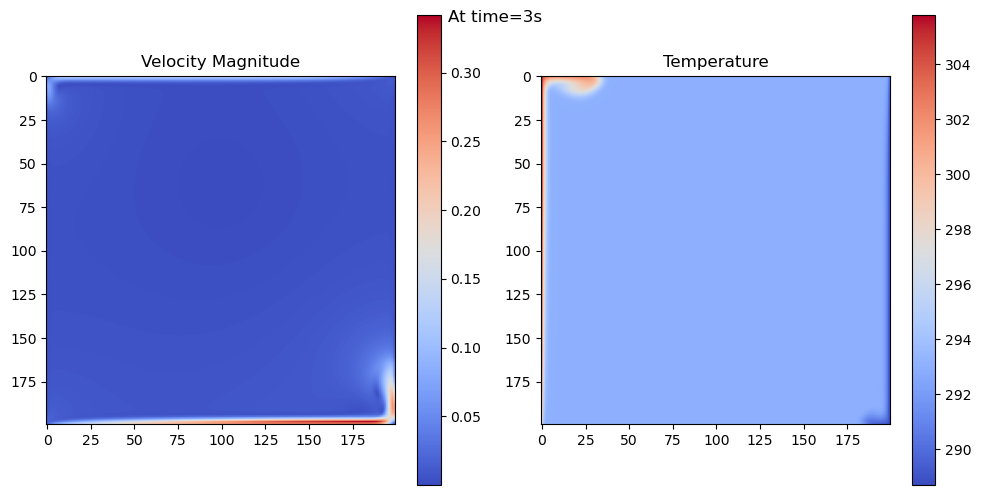

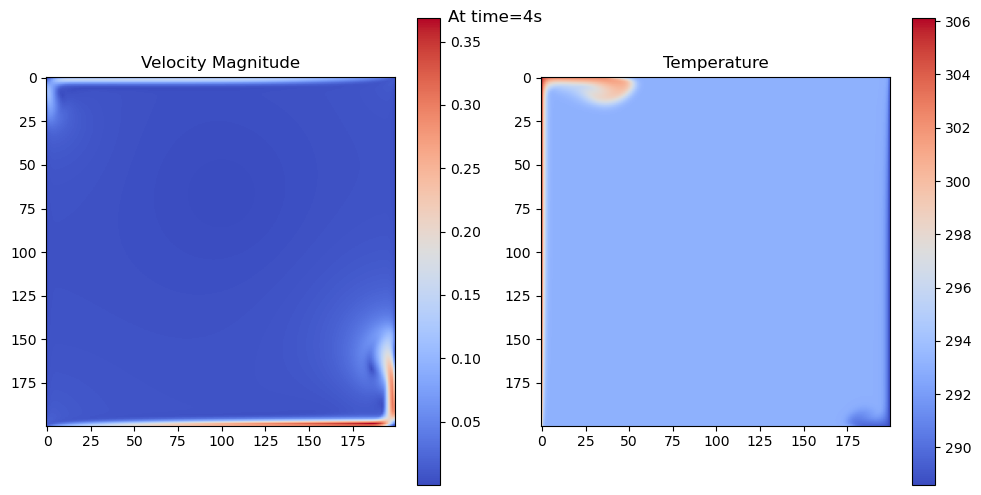

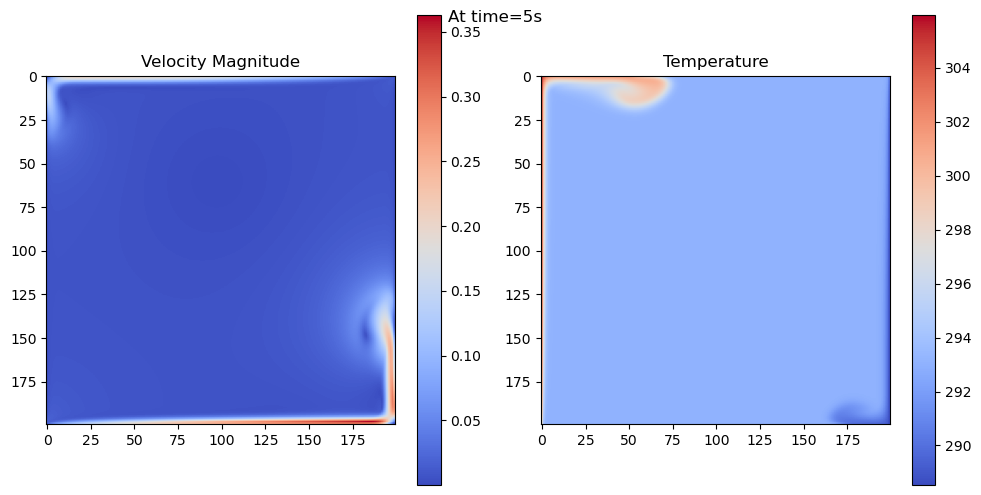

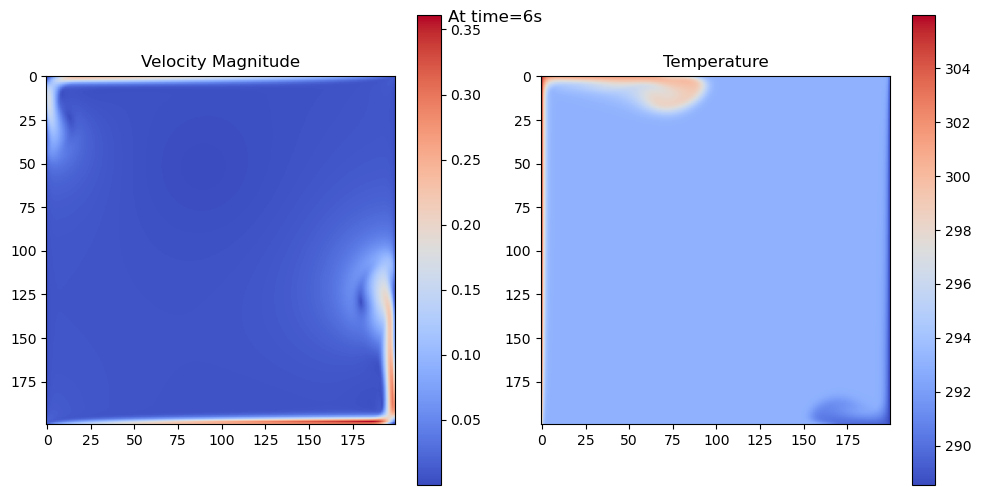

In [6]:
for i in range(1,7):
	visualize_output(assets_dir, i)


In [138]:
import timeit

def test():
	x = np.random.rand(200,200)
	print(x.shape)

print(timeit.default_timer())
test()
print(timeit.default_timer())

1235321.299720943
(200, 200)
<class 'float'>


In [166]:
prediction_input = None
prediction_input = np.random.rand(200,200,3)

In [149]:
x = np.random.rand(200,200)
y = np.random.rand(200,200)

z = np.concatenate([x.reshape(-1,1), y.reshape(-1,1)], axis=1)

In [151]:
z[:,0:1] == x.reshape(-1,1)

array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])